ASSIGNMENT 9


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

# Load MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [4]:
latent_dim = 2

# Encoder
encoder_input = keras.Input(shape=(784,))

x = layers.Dense(128, activation="relu")(encoder_input)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# Simple latent representation
z = z_mean

encoder = keras.Model(encoder_input, z, name="encoder")


# Decoder
decoder_input = keras.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(decoder_input)
decoder_output = layers.Dense(784, activation="sigmoid")(x)

decoder = keras.Model(decoder_input, decoder_output, name="decoder")


# Complete VAE
vae_input = keras.Input(shape=(784,))
encoded = encoder(vae_input)
decoded = decoder(encoded)

vae = keras.Model(vae_input, decoded)

vae.compile(
    optimizer="adam",
    loss="mse"
)

print("VAE created successfully!")

VAE created successfully!


In [5]:
history = vae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0658 - val_loss: 0.0547
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0523 - val_loss: 0.0499
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0490 - val_loss: 0.0478
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0475 - val_loss: 0.0466
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0465 - val_loss: 0.0459


In [6]:
original_size = 784
latent_size = 2

compression_ratio = original_size / latent_size

print("Original image size:", original_size)
print("Latent representation size:", latent_size)
print("Compression ratio:", compression_ratio, ":1")

Original image size: 784
Latent representation size: 2
Compression ratio: 392.0 :1


In [7]:
# Select 10 images
images = x_test[:10]

# Encode
encoded_images = encoder.predict(images)

# Decode
reconstructed_images = decoder.predict(encoded_images)

# Calculate MSE
mse = np.mean((images - reconstructed_images) ** 2, axis=1)

for i in range(10):
    print(f"Image {i+1} MSE: {mse[i]:.6f}")

print("Average MSE:", np.mean(mse))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Image 1 MSE: 0.031300
Image 2 MSE: 0.070930
Image 3 MSE: 0.010515
Image 4 MSE: 0.042494
Image 5 MSE: 0.041799
Image 6 MSE: 0.005578
Image 7 MSE: 0.053960
Image 8 MSE: 0.049562
Image 9 MSE: 0.076630
Image 10 MSE: 0.043099
Average MSE: 0.042586602


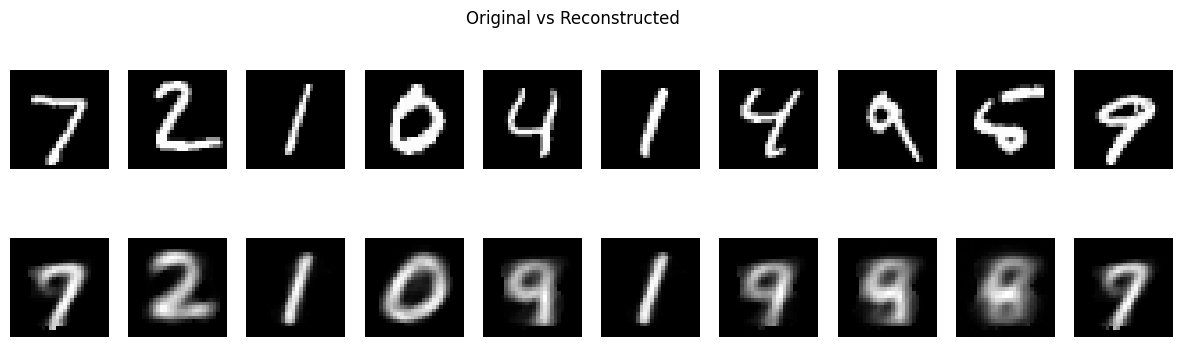

In [8]:
plt.figure(figsize=(15, 4))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original vs Reconstructed")
plt.show()

In [9]:
# Add Gaussian noise
noise = np.random.normal(0, 0.3, images.shape)

noisy_images = images + noise

# Keep values between 0 and 1
noisy_images = np.clip(noisy_images, 0, 1)

# Pass noisy images through VAE
encoded_noisy = encoder.predict(noisy_images)
denoised_images = decoder.predict(encoded_noisy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


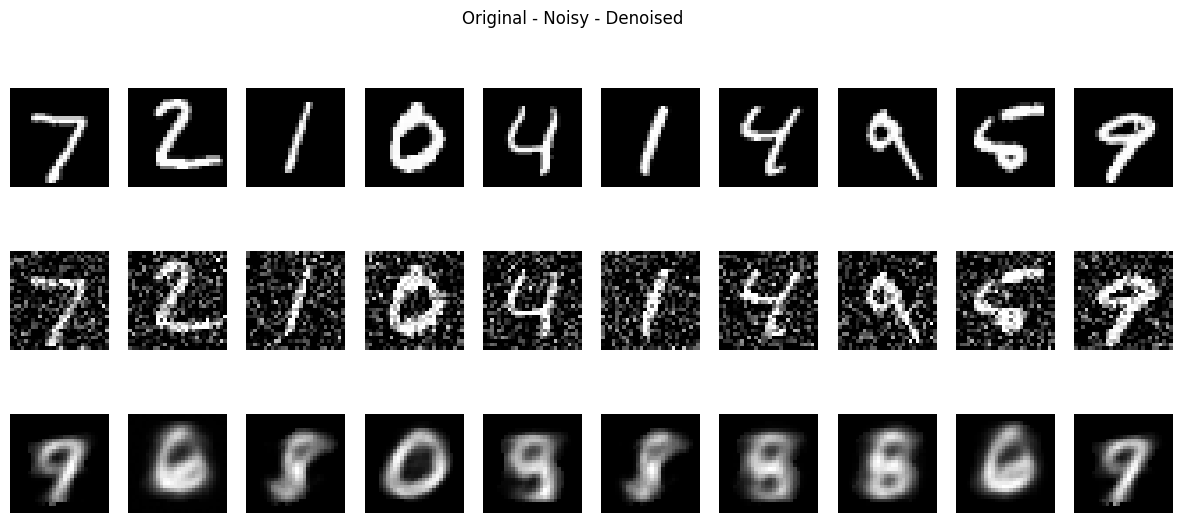

In [10]:
plt.figure(figsize=(15, 6))

for i in range(10):

    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Noisy
    plt.subplot(3, 10, i + 11)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Denoised
    plt.subplot(3, 10, i + 21)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original - Noisy - Denoised")

plt.show()

In [11]:
def create_autoencoder(latent_dim):

    # Encoder
    encoder_input = keras.Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(encoder_input)
    encoded = layers.Dense(latent_dim, activation="relu")(x)

    encoder = keras.Model(encoder_input, encoded)

    # Decoder
    decoder_input = keras.Input(shape=(latent_dim,))
    x = layers.Dense(128, activation="relu")(decoder_input)
    decoded = layers.Dense(784, activation="sigmoid")(x)

    decoder = keras.Model(decoder_input, decoded)

    # Autoencoder
    inputs = keras.Input(shape=(784,))
    encoded_output = encoder(inputs)
    decoded_output = decoder(encoded_output)

    autoencoder = keras.Model(inputs, decoded_output)

    autoencoder.compile(
        optimizer="adam",
        loss="mse"
    )

    return autoencoder, encoder, decoder

In [12]:
ae16, encoder16, decoder16 = create_autoencoder(16)

ae16.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0472
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0260
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0223
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0207
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0194


In [13]:
recon16 = ae16.predict(images)

mse16 = np.mean(
    (images - recon16) ** 2
)

print("Latent 16 MSE:", mse16)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Latent 16 MSE: 0.018165894


In [14]:
ae32, encoder32, decoder32 = create_autoencoder(32)

ae32.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0441
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0193
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0148
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0129
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0119


In [15]:
recon32 = ae32.predict(images)

mse32 = np.mean(
    (images - recon32) ** 2
)

print("Latent 32 MSE:", mse32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Latent 32 MSE: 0.010753665


In [16]:
mse2 = np.mean(mse)

results = pd.DataFrame({
    "Latent Dimension": [2, 16, 32],
    "Compression Ratio": ["392:1", "49:1", "24.5:1"],
    "Reconstruction Error": [mse2, mse16, mse32],
    "Reconstruction Quality": [
        "Basic / blurry",
        "Better",
        "Best"
    ],
    "Denoising Observation": [
        "Moderate noise removal",
        "Better noise removal",
        "Better detail preservation"
    ]
})

results

,Latent Dimension,Compression Ratio,Reconstruction Error,Reconstruction Quality,Denoising Observation
0,2,392:1,0.042587,Basic / blurry,Moderate noise removal
1,16,49:1,0.018166,Better,Better noise removal
2,32,24.5:1,0.010754,Best,Better detail preservation


Conclusion:

 The autoencoder was able to compress MNIST images into smaller latent representations and reconstruct them. Increasing the latent dimension from 2 to 16 and 32 improved reconstruction quality because more information could be stored in the latent representation. However, a larger latent dimension resulted in a lower compression ratio. The model also reduced some of the Gaussian noise when noisy images were passed through the trained model.